# Assignment 7 — Incremental Data Processing with Delta Lake

**Objective —** load a customer dataset into a Delta table, clean it, simulate an
incremental (change) feed, apply a `MERGE` operation to upsert the changes, validate the
result and publish a final dataset with a summary.

| | |
|---|---|
| **Source data** | `Sample - Superstore` order lines (9,994 rows) aggregated into a customer dimension |
| **Master snapshot** | `data/customer_master.csv` — 866 rows (contains nulls, duplicates, dirty strings) |
| **Incremental feed** | `data/customer_incremental.csv` — 162 rows (updates + new customers + duplicate source rows) |
| **Storage format** | Delta Lake (ACID transaction log, versioned, time-travel) |
| **Engine** | `deltalake` — the native Rust implementation of the Delta protocol (`delta-io/delta-rs`) |

### Why `delta-rs` and not PySpark?

Delta Lake has two official engines: **Delta Spark** (JVM) and **delta-rs** (native).
Both write the *same* Delta transaction log, so tables produced here are readable by
Spark and Databricks. `delta-rs` is used as the primary engine because it installs with a
single `pip install deltalake`, needs no JVM/Java/Maven, and therefore runs identically on
a laptop, in Colab and in a grading environment — nothing to configure, nothing to break.

> A **line-for-line PySpark + Delta Spark version** of this same notebook is included at
> `notebooks/delta_scd_assignment_pyspark.ipynb` for anyone who wants to run it on
> Databricks / a Spark cluster. The logic, the `MERGE` semantics and the results are identical.

### Contents

| Step | What happens |
|---|---|
| 1 | Load the raw CSV into a **bronze** Delta table |
| 2 | Clean it — nulls, duplicates, dirty strings, types — into a **silver** Delta table |
| 3 | Load and clean the incremental feed, classify every row as *new / changed / unchanged* |
| 4 | **`MERGE`** — SCD Type 1 (overwrite in place) |
| 5 | **`MERGE`** — SCD Type 2 (keep full history with effective dates) |
| 6 | Validate — row counts, duplicates, primary keys, history integrity, time travel |
| 7 | Final dataset, business summary, charts and exports |

---
## 0. Environment

If `deltalake` is not installed yet, uncomment and run the install cell below.

In [2]:
import hashlib
import json
import os
import shutil
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa

import deltalake
from deltalake import DeltaTable, write_deltalake

print("python    :", sys.version.split()[0])
print("pandas    :", pd.__version__)
print("pyarrow   :", pa.__version__)
print("deltalake :", deltalake.__version__, " (delta-rs — native Delta Lake protocol)")
print("matplotlib:", matplotlib.__version__)
print("\nEnvironment ready.")

python    : 3.12.0
pandas    : 2.3.3
pyarrow   : 25.0.0
deltalake : 1.6.2  (delta-rs — native Delta Lake protocol)
matplotlib: 3.11.0

Environment ready.


### 0.1 Configuration and helpers

Everything the notebook needs is defined once here: paths, the batch timestamp, the list of
attributes that are *tracked for change* (used by the SCD Type 2 hash), and a handful of small
display / conversion helpers.

In [3]:
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_DIR   = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
SHOTS_DIR  = PROJECT_ROOT / "screenshots"
LAKE_DIR   = OUTPUT_DIR / "delta_lake"

MASTER_CSV = DATA_DIR / "customer_master.csv"
INCR_CSV   = DATA_DIR / "customer_incremental.csv"

TBL_BRONZE = LAKE_DIR / "bronze_customer_raw"
TBL_SILVER = LAKE_DIR / "silver_customer_master"
TBL_SCD1   = LAKE_DIR / "gold_customer_scd1"
TBL_SCD2   = LAKE_DIR / "gold_customer_scd2"

RESET_LAKE = True

SNAPSHOT_TS = pd.Timestamp("2019-12-31 22:00:00", tz="UTC")
BATCH_TS    = pd.Timestamp("2020-01-15 06:30:00", tz="UTC")

BUSINESS_KEY = "customer_id"

TRACKED_ATTRS = [
    "segment", "city", "state", "postal_code", "region",
    "loyalty_tier", "email", "total_orders", "total_sales",
    "total_profit", "last_order_date",
]

DATE_COLS = ["last_order_date"]
TS_COLS   = ["record_updated_at", "effective_start_date", "effective_end_date"]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if RESET_LAKE and LAKE_DIR.exists():
    shutil.rmtree(LAKE_DIR)
LAKE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 26)

print(f"project root : {PROJECT_ROOT}")
print(f"delta lake   : {LAKE_DIR}")
print(f"master csv   : {MASTER_CSV.name}  (exists={MASTER_CSV.exists()})")
print(f"incr   csv   : {INCR_CSV.name}  (exists={INCR_CSV.exists()})")
print(f"reset lake   : {RESET_LAKE}")

project root : C:\Users\USER\Desktop\CelebalAssignments\week7
delta lake   : C:\Users\USER\Desktop\CelebalAssignments\week7\output\delta_lake
master csv   : customer_master.csv  (exists=True)
incr   csv   : customer_incremental.csv  (exists=True)
reset lake   : True


In [4]:
def banner(title, char="=", width=96):
    print(char * width)
    print(title)
    print(char * width)


def show(df, n=10, cols=None, title=None):
    if title:
        print(title)
    frame = df[cols] if cols else df
    print(frame.head(n).to_string(index=False))
    print(f"... [{len(df):,} rows x {len(frame.columns)} columns]")


def to_arrow(df):
    tbl = pa.Table.from_pandas(df, preserve_index=False)
    for name in tbl.column_names:
        idx = tbl.schema.get_field_index(name)
        typ = tbl.schema.field(name).type
        if name in DATE_COLS and not pa.types.is_date(typ):
            tbl = tbl.set_column(idx, name, tbl.column(name).cast(pa.date32()))
        elif pa.types.is_null(typ):
            tbl = tbl.set_column(idx, name, tbl.column(name).cast(pa.string()))
    return tbl


def hash_row(df, cols):
    tmp = df[cols].copy()
    for c in tmp.columns:
        if pd.api.types.is_datetime64_any_dtype(tmp[c]):
            tmp[c] = tmp[c].dt.strftime("%Y-%m-%d")
    joined = tmp.astype(str).agg("|".join, axis=1)
    return joined.map(lambda s: hashlib.md5(s.encode("utf-8")).hexdigest())


def loyalty_tier(total_sales):
    if total_sales >= 5000:  return "PLATINUM"
    if total_sales >= 2500:  return "GOLD"
    if total_sales >= 1000:  return "SILVER"
    return "BRONZE"


def quality_profile(df, key=BUSINESS_KEY):
    prof = pd.DataFrame({
        "dtype":       df.dtypes.astype(str),
        "nulls":       df.isna().sum(),
        "null_pct":    (df.isna().mean() * 100).round(2),
        "distinct":    df.nunique(dropna=True),
    })
    prof.index.name = "column"
    summary = {
        "rows": len(df),
        "exact_duplicate_rows": int(df.duplicated().sum()),
        f"duplicate_{key}": int(df[key].duplicated().sum()),
        f"distinct_{key}": int(df[key].nunique(dropna=True)),
        "columns_with_nulls": int((df.isna().sum() > 0).sum()),
        "total_null_cells": int(df.isna().sum().sum()),
    }
    return prof, summary


print("helpers defined: banner, show, to_arrow, hash_row, loyalty_tier, quality_profile")

helpers defined: banner, show, to_arrow, hash_row, loyalty_tier, quality_profile


---
## 1. Load the dataset into a Delta table

The raw CSV is read **entirely as text** (`dtype=str`). This is the standard *bronze layer*
contract: land the source exactly as it arrived, do not let the reader silently guess types
or drop leading zeros from postal codes. Typing happens in the cleaning step.

In [5]:
master_raw = pd.read_csv(MASTER_CSV, dtype=str, keep_default_na=True)

banner("RAW MASTER SNAPSHOT — data/customer_master.csv")
print(f"shape: {master_raw.shape[0]:,} rows x {master_raw.shape[1]} columns\n")
print("columns:", list(master_raw.columns), "\n")
show(master_raw, 8, cols=["customer_id", "customer_name", "segment", "city",
                          "region", "total_orders", "total_sales", "loyalty_tier",
                          "record_updated_at"])

RAW MASTER SNAPSHOT — data/customer_master.csv
shape: 866 rows x 15 columns

columns: ['customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'total_orders', 'total_sales', 'total_profit', 'last_order_date', 'loyalty_tier', 'email', 'record_updated_at'] 

customer_id    customer_name     segment          city  region total_orders total_sales loyalty_tier   record_updated_at
   DK-12895      Dana Kaydos    Consumer       Seattle    West            5     4282.18         GOLD 2019-12-31 22:00:00
   MA-17995  Michelle Arnett Home Office      Richmond   South            6     2453.28       SILVER 2019-12-31 22:00:00
   RO-19780     Rose O'Brian    Consumer       Houston Central            7     3815.48         GOLD 2019-12-31 22:00:00
   SC-20050 Sample Company A Home Office       Burbank    West            9     4624.57         GOLD 2019-12-31 22:00:00
   AG-10525     Andy Gerbode   Corporate New York City    East            4     1455.04       SILV

In [6]:
prof_before, summary_before = quality_profile(master_raw)

banner("DATA QUALITY PROFILE — BEFORE CLEANING")
print(prof_before.to_string())
print()
for k, v in summary_before.items():
    print(f"  {k:<26} : {v:,}")

print("\nExamples of dirty values that need fixing:")
dirty_seg = master_raw.loc[master_raw["segment"].astype(str).str.match(r"^\s|.*\s$", na=False),
                           ["customer_id", "segment", "region"]].head(4)
print(dirty_seg.to_string(index=False))
print("\n  (leading/trailing whitespace and inconsistent casing above)")

DATA QUALITY PROFILE — BEFORE CLEANING
                    dtype  nulls  null_pct  distinct
column                                              
customer_id        object      3      0.35       793
customer_name      object      0      0.00       793
segment            object     18      2.08         6
country            object      0      0.00         1
city               object     14      1.62       221
state              object      0      0.00        44
postal_code        object     34      3.93       277
region             object      8      0.92         8
total_orders       object      0      0.00        14
total_sales        object     10      1.15       808
total_profit       object      0      0.00       793
last_order_date    object      0      0.00       300
loyalty_tier       object      6      0.69         4
email              object     43      4.97       753
record_updated_at  object      0      0.00         2

  rows                       : 866
  exact_duplicate_rows  

### 1.1 Write the raw snapshot to a Delta table (bronze)

`write_deltalake(..., mode="overwrite")` creates the table directory, writes Parquet data
files and commits `_delta_log/00000000000000000000.json`. That JSON commit is what makes
this a *Delta* table rather than a folder of Parquet: it gives us ACID commits, schema
enforcement, versioning and time travel.

In [7]:
write_deltalake(str(TBL_BRONZE), to_arrow(master_raw), mode="overwrite")

bronze = DeltaTable(str(TBL_BRONZE))

banner("BRONZE DELTA TABLE — bronze_customer_raw")
print(f"location    : {TBL_BRONZE}")
print(f"version     : {bronze.version()}")
print(f"row count   : {bronze.count():,}")
print(f"data files  : {len(bronze.file_uris())}")
print(f"protocol    : {bronze.protocol()}")
print("\nschema:")
for f in bronze.schema().fields:
    print(f"  {f.name:<22} {str(f.type).replace('PrimitiveType', '').strip('()\"')}")

print("\ntransaction log (_delta_log):")
for entry in os.listdir(TBL_BRONZE / "_delta_log"):
    print("  ", entry)

print("\ncommit history:")
for h in bronze.history():
    print(f"  v{h['version']}  {h['operation']:<10} rows={h.get('operationMetrics', {}).get('num_output_rows', '-')}")

BRONZE DELTA TABLE — bronze_customer_raw
location    : C:\Users\USER\Desktop\CelebalAssignments\week7\output\delta_lake\bronze_customer_raw
version     : 0
row count   : 866
data files  : 1
protocol    : ProtocolVersions(min_reader_version=1, min_writer_version=2, writer_features=None, reader_features=None)

schema:
  customer_id            string
  customer_name          string
  segment                string
  country                string
  city                   string
  state                  string
  postal_code            string
  region                 string
  total_orders           string
  total_sales            string
  total_profit           string
  last_order_date        date
  loyalty_tier           string
  email                  string
  record_updated_at      string

transaction log (_delta_log):
   00000000000000000000.json

commit history:
  v0  WRITE      rows=-


### 1.2 Load the incremental feed

This is the "next batch" arriving from the source system — a mixture of **updates to existing
customers**, **brand-new customers**, and (as happens in real feeds) a few **duplicated rows**.

In [8]:
incr_raw = pd.read_csv(INCR_CSV, dtype=str, keep_default_na=True)

banner("RAW INCREMENTAL FEED — data/customer_incremental.csv")
print(f"shape: {incr_raw.shape[0]:,} rows x {incr_raw.shape[1]} columns")
print(f"distinct customer_id : {incr_raw['customer_id'].nunique():,}")
print(f"duplicated rows      : {incr_raw.duplicated().sum()}")
print(f"duplicated keys      : {incr_raw['customer_id'].duplicated().sum()}\n")

existing = set(master_raw["customer_id"].dropna())
in_feed = incr_raw["customer_id"]
print(f"rows whose customer_id already exists in master : {in_feed.isin(existing).sum():,}")
print(f"rows whose customer_id is brand new             : {(~in_feed.isin(existing)).sum():,}\n")

show(incr_raw, 8, cols=["customer_id", "customer_name", "segment", "city",
                        "region", "total_sales", "loyalty_tier", "last_order_date"])

RAW INCREMENTAL FEED — data/customer_incremental.csv
shape: 162 rows x 15 columns
distinct customer_id : 157
duplicated rows      : 5
duplicated keys      : 5

rows whose customer_id already exists in master : 114
rows whose customer_id is brand new             : 48

customer_id    customer_name     segment          city  region total_sales loyalty_tier last_order_date
   TP-21565     Tracy Poddar Home Office        Eugene    West     2144.31       SILVER      2020-01-15
   CY-12745     Craig Yedwab   Corporate       Chicago Central     2900.03         GOLD      2017-10-31
   EP-20133    Elena Petrova   Corporate       Houston Central     5800.79     PLATINUM      2020-01-15
   KB-16405 Katrina Bavinger Home Office New York City    East     1415.34       SILVER      2020-01-15
   SS-20410  Shahid Shariari    Consumer   Los Angeles    West     4459.17         GOLD      2020-01-15
   DH-13675    Duane Huffman Home Office         Miami   South     1236.05       SILVER      2020-01-15
   C

---
## 2. Basic cleaning

One function does the whole cleaning contract so that the master snapshot and the incremental
feed are guaranteed to be processed **identically** — a mismatch between the two would silently
corrupt the `MERGE`.

| # | Rule | Why |
|---|---|---|
| 1 | Trim whitespace, collapse repeated spaces, standardise casing | `"  CONSUMER "` and `"Consumer"` must not become two different segments |
| 2 | Empty strings → `NULL` | `""` is not a value |
| 3 | Drop rows with a `NULL` business key | a row without `customer_id` can never be merged |
| 4 | Drop **exact duplicate rows** | classic double-load artefact |
| 5 | Deduplicate on `customer_id`, keeping the **latest** `record_updated_at` | `MERGE` fails if one source row matches a target row more than once |
| 6 | Cast to proper types (int / float / date / timestamp) | enables arithmetic, range filters and Delta schema enforcement |
| 7 | Impute remaining nulls with documented defaults | keeps the dimension complete and joinable |

In [9]:
def clean_customer_frame(df, label="dataset", verbose=True):
    out = df.copy()
    rep = {"rows_in": len(out)}

    for c in out.columns:
        out[c] = out[c].astype("string").str.strip()
    out = out.replace({"": pd.NA})
    out["customer_name"] = out["customer_name"].str.replace(r"\s+", " ", regex=True)
    out["segment"]       = out["segment"].str.title()
    out["region"]        = out["region"].str.title()
    out["city"]          = out["city"].str.title()
    out["loyalty_tier"]  = out["loyalty_tier"].str.upper()
    out["email"]         = out["email"].str.lower()

    n = len(out)
    out = out[out[BUSINESS_KEY].notna()]
    rep["dropped_null_key"] = n - len(out)

    n = len(out)
    out = out.drop_duplicates()
    rep["dropped_exact_duplicates"] = n - len(out)

    n = len(out)
    out = (out.sort_values([BUSINESS_KEY, "record_updated_at"], ascending=[True, False])
              .drop_duplicates(subset=[BUSINESS_KEY], keep="first"))
    rep["dropped_duplicate_keys"] = n - len(out)

    out["total_orders"] = pd.to_numeric(out["total_orders"], errors="coerce").fillna(0).astype("int64")
    out["total_sales"]  = pd.to_numeric(out["total_sales"],  errors="coerce").astype("float64").round(2)
    out["total_profit"] = pd.to_numeric(out["total_profit"], errors="coerce").astype("float64").round(2)
    out["last_order_date"]   = pd.to_datetime(out["last_order_date"], errors="coerce").astype("datetime64[us]")
    out["record_updated_at"] = (pd.to_datetime(out["record_updated_at"], errors="coerce")
                                  .dt.tz_localize("UTC").astype("datetime64[us, UTC]"))

    rep["nulls_filled"] = int(out.isna().sum().sum())
    fill_defaults = {
        "segment": "Unknown", "city": "Unknown", "state": "Unknown",
        "region": "Unknown", "postal_code": "00000", "country": "United States",
    }
    for col, default in fill_defaults.items():
        out[col] = out[col].fillna(default)
    out["total_sales"]  = out["total_sales"].fillna(0.0)
    out["total_profit"] = out["total_profit"].fillna(0.0)
    out["loyalty_tier"] = out["loyalty_tier"].where(out["loyalty_tier"].notna(),
                                                    out["total_sales"].map(loyalty_tier))
    slug = (out["customer_name"].str.lower()
                                .str.replace(r"[^a-z ]", "", regex=True)
                                .str.strip()
                                .str.replace(" ", ".", regex=False))
    out["email"] = out["email"].fillna(slug + "@unknown.local")

    for c in ["customer_id", "customer_name", "segment", "country", "city",
              "state", "postal_code", "region", "loyalty_tier", "email"]:
        out[c] = out[c].astype(str)

    out = out.sort_values(BUSINESS_KEY).reset_index(drop=True)
    rep["rows_out"] = len(out)
    rep["rows_removed"] = rep["rows_in"] - rep["rows_out"]
    rep["remaining_nulls"] = int(out.isna().sum().sum())

    if verbose:
        banner(f"CLEANING REPORT — {label}")
        for k, v in rep.items():
            print(f"  {k:<26} : {v:,}")
    return out, rep


print("clean_customer_frame() defined")

clean_customer_frame() defined


In [10]:
master_clean, master_report = clean_customer_frame(master_raw, "customer_master.csv")

print()
print(f"  {master_report['rows_in']:,} raw rows  ->  {master_report['rows_out']:,} clean rows "
      f"({master_report['rows_removed']:,} removed)")
print("\nfinal dtypes:")
print(master_clean.dtypes.to_string())

CLEANING REPORT — customer_master.csv
  rows_in                    : 866
  dropped_null_key           : 3
  dropped_exact_duplicates   : 45
  dropped_duplicate_keys     : 25
  nulls_filled               : 123
  rows_out                   : 793
  rows_removed               : 73
  remaining_nulls            : 0

  866 raw rows  ->  793 clean rows (73 removed)

final dtypes:
column
customer_id                       object
customer_name                     object
segment                           object
country                           object
city                              object
state                             object
postal_code                       object
region                            object
total_orders                       int64
total_sales                      float64
total_profit                     float64
last_order_date           datetime64[us]
loyalty_tier                      object
email                             object
record_updated_at    datetime64[us, UTC]


In [11]:
prof_after, summary_after = quality_profile(master_clean)

banner("DATA QUALITY PROFILE — AFTER CLEANING")
print(prof_after.to_string())

comparison = pd.DataFrame(
    {"before": summary_before, "after": summary_after}
).assign(delta=lambda d: d["after"] - d["before"])

print("\nbefore / after summary:")
print(comparison.to_string())

assert master_clean[BUSINESS_KEY].notna().all(),          "null business key survived cleaning"
assert not master_clean.duplicated().any(),               "exact duplicate rows survived cleaning"
assert not master_clean[BUSINESS_KEY].duplicated().any(), "duplicate customer_id survived cleaning"
assert master_clean.isna().sum().sum() == 0,              "null values survived cleaning"
print("\nAll post-cleaning assertions passed: no nulls, no duplicates, unique primary key.")

DATA QUALITY PROFILE — AFTER CLEANING
                                 dtype  nulls  null_pct  distinct
column                                                           
customer_id                     object      0       0.0       793
customer_name                   object      0       0.0       793
segment                         object      0       0.0         4
country                         object      0       0.0         1
city                            object      0       0.0       222
state                           object      0       0.0        44
postal_code                     object      0       0.0       278
region                          object      0       0.0         5
total_orders                     int64      0       0.0        14
total_sales                    float64      0       0.0       784
total_profit                   float64      0       0.0       793
last_order_date         datetime64[us]      0       0.0       300
loyalty_tier                    object

In [12]:
banner("BEFORE / AFTER — a few records that were actually repaired")

dirty_ids = (master_raw.loc[master_raw[["segment", "city", "region", "email", "loyalty_tier"]]
                            .isna().any(axis=1), "customer_id"].dropna().unique()[:4])

cols = ["customer_id", "segment", "city", "region", "loyalty_tier", "email"]
print("RAW:")
print(master_raw[master_raw["customer_id"].isin(dirty_ids)][cols].to_string(index=False))
print("\nCLEAN:")
print(master_clean[master_clean["customer_id"].isin(dirty_ids)][cols].to_string(index=False))

print("\nDuplicate handling — a late-arriving record: same customer_id, two different versions")
ts_per_key = master_raw.dropna(subset=["customer_id"]).groupby("customer_id")["record_updated_at"].nunique()
dup_id = ts_per_key[ts_per_key > 1].index[0]
print(master_raw[master_raw["customer_id"] == dup_id]
      [["customer_id", "total_sales", "loyalty_tier", "record_updated_at"]]
      .sort_values("record_updated_at").to_string(index=False))
print("  -> kept (latest record_updated_at wins):")
print(master_clean[master_clean["customer_id"] == dup_id]
      [["customer_id", "total_sales", "loyalty_tier", "record_updated_at"]].to_string(index=False))

print("\nExact-duplicate handling — the same row landed twice:")
exact_dup_id = master_raw[master_raw.duplicated(keep=False)]["customer_id"].dropna().iloc[0]
print(f"  customer_id {exact_dup_id}: "
      f"{int((master_raw['customer_id'] == exact_dup_id).sum())} raw rows -> "
      f"{int((master_clean['customer_id'] == exact_dup_id).sum())} clean row")

BEFORE / AFTER — a few records that were actually repaired
RAW:
customer_id  segment          city  region loyalty_tier                      email
   NP-18325 Consumer New York City    East          NaN   naresj.patel@example.com
   BD-11320      NaN   Los Angeles    West     PLATINUM bill.donatelli@example.com
   JF-15295 Consumer         Logan    West       BRONZE                        NaN
   PK-19075 Consumer           NaN Central     PLATINUM                        NaN
   PK-19075 Consumer           NaN Central     PLATINUM                        NaN

CLEAN:
customer_id  segment          city  region loyalty_tier                       email
   BD-11320  Unknown   Los Angeles    West     PLATINUM  bill.donatelli@example.com
   JF-15295 Consumer         Logan    West       BRONZE jason.fortune@unknown.local
   NP-18325 Consumer New York City    East     PLATINUM    naresj.patel@example.com
   PK-19075 Consumer       Unknown Central     PLATINUM     pete.kriz@unknown.local

Duplicate

### 2.1 Persist the cleaned snapshot (silver)

In [13]:
write_deltalake(str(TBL_SILVER), to_arrow(master_clean), mode="overwrite")
silver = DeltaTable(str(TBL_SILVER))

banner("SILVER DELTA TABLE — silver_customer_master")
print(f"location  : {TBL_SILVER}")
print(f"version   : {silver.version()}")
print(f"row count : {silver.count():,}")
print(f"protocol  : {silver.protocol()}\n")
print("schema (Delta types):")
for f in silver.schema().fields:
    print(f"  {f.name:<22} {str(f.type).replace('PrimitiveType', '').strip('()\"')}")

print()
show(silver.to_pandas(), 8,
     cols=["customer_id", "customer_name", "segment", "city", "region",
           "total_orders", "total_sales", "loyalty_tier"],
     title="silver table contents:")

SILVER DELTA TABLE — silver_customer_master
location  : C:\Users\USER\Desktop\CelebalAssignments\week7\output\delta_lake\silver_customer_master
version   : 0
row count : 793
protocol  : ProtocolVersions(min_reader_version=1, min_writer_version=2, writer_features=None, reader_features=None)

schema (Delta types):
  customer_id            string
  customer_name          string
  segment                string
  country                string
  city                   string
  state                  string
  postal_code            string
  region                 string
  total_orders           long
  total_sales            double
  total_profit           double
  last_order_date        date
  loyalty_tier           string
  email                  string
  record_updated_at      timestamp

silver table contents:
customer_id   customer_name     segment          city  region  total_orders  total_sales loyalty_tier
   AA-10315      Alex Avila    Consumer    Round Rock Central             5      

In [14]:
incr_clean, incr_report = clean_customer_frame(incr_raw, "customer_incremental.csv")

print()
print("Why de-duplicating the source matters:")
print(f"  the feed contained {incr_report['dropped_exact_duplicates']} duplicated row(s).")
print("  A MERGE whose source matches one target row more than once fails with")
print("  'multiple source rows matched the same target row' — de-duplication prevents that.\n")
show(incr_clean, 8,
     cols=["customer_id", "customer_name", "segment", "city", "region",
           "total_sales", "loyalty_tier", "last_order_date"],
     title="cleaned incremental feed:")

CLEANING REPORT — customer_incremental.csv
  rows_in                    : 162
  dropped_null_key           : 0
  dropped_exact_duplicates   : 5
  dropped_duplicate_keys     : 0
  nulls_filled               : 7
  rows_out                   : 157
  rows_removed               : 5
  remaining_nulls            : 0

Why de-duplicating the source matters:
  the feed contained 5 duplicated row(s).
  A MERGE whose source matches one target row more than once fails with
  'multiple source rows matched the same target row' — de-duplication prevents that.

cleaned incremental feed:
customer_id       customer_name     segment          city  region  total_sales loyalty_tier last_order_date
   AA-10645       Anna Andreadi    Consumer        Denver    West      5623.56     PLATINUM      2020-01-15
   AB-10060     Adam Bellavance Home Office New York City    East      9050.56     PLATINUM      2020-01-15
   AB-20035         Ananya Bose Home Office       Phoenix    West      6219.65     PLATINUM      20

### 2.2 Classify every incoming row

Before merging, it is worth knowing exactly what the batch is going to do. Each incoming row is
compared against the current silver snapshot using an MD5 hash of the tracked attributes:

* **NEW** — `customer_id` not present in the target → will be **inserted**
* **CHANGED** — key present but hash differs → will be **updated** (SCD1) / **versioned** (SCD2)
* **UNCHANGED** — key present and hash identical → **no-op**

These three numbers become the expected values that the validation step asserts against.

In [15]:
target_hashes = pd.DataFrame({
    BUSINESS_KEY: master_clean[BUSINESS_KEY],
    "target_hash": hash_row(master_clean, TRACKED_ATTRS),
})
incr_clean["record_hash"] = hash_row(incr_clean, TRACKED_ATTRS)

classified = incr_clean.merge(target_hashes, on=BUSINESS_KEY, how="left")
classified["change_type"] = np.where(
    classified["target_hash"].isna(), "NEW",
    np.where(classified["target_hash"] != classified["record_hash"], "CHANGED", "UNCHANGED"),
)

EXPECTED = classified["change_type"].value_counts().to_dict()
EXPECTED_NEW       = int(EXPECTED.get("NEW", 0))
EXPECTED_CHANGED   = int(EXPECTED.get("CHANGED", 0))
EXPECTED_UNCHANGED = int(EXPECTED.get("UNCHANGED", 0))

banner("CHANGE CLASSIFICATION OF THE INCREMENTAL BATCH")
print(classified["change_type"].value_counts().to_frame("rows").to_string())
print(f"\n  total incoming rows      : {len(classified):,}")
print(f"  -> will be INSERTED      : {EXPECTED_NEW:,}")
print(f"  -> will be UPDATED       : {EXPECTED_CHANGED:,}")
print(f"  -> no-op (identical)     : {EXPECTED_UNCHANGED:,}")
print(f"\n  target rows before merge : {len(master_clean):,}")
print(f"  target rows after  merge : {len(master_clean) + EXPECTED_NEW:,}  (expected)")

print("\nsample of each class:")
for kind in ["NEW", "CHANGED", "UNCHANGED"]:
    sub = classified[classified["change_type"] == kind]
    if len(sub):
        print(f"\n  {kind}:")
        print(sub[["customer_id", "customer_name", "segment", "city",
                   "total_sales", "loyalty_tier"]].head(3).to_string(index=False))

CHANGE CLASSIFICATION OF THE INCREMENTAL BATCH
             rows
change_type      
CHANGED       101
NEW            45
UNCHANGED      11

  total incoming rows      : 157
  -> will be INSERTED      : 45
  -> will be UPDATED       : 101
  -> no-op (identical)     : 11

  target rows before merge : 793
  target rows after  merge : 838  (expected)

sample of each class:

  NEW:
customer_id customer_name     segment          city  total_sales loyalty_tier
   AB-20035   Ananya Bose Home Office       Phoenix      6219.65     PLATINUM
   AH-20245    Alice Hale Home Office       Houston      5798.13     PLATINUM
   AM-20056   Arjun Mehta Home Office New York City      3194.47         GOLD

  CHANGED:
customer_id       customer_name     segment          city  total_sales loyalty_tier
   AA-10645       Anna Andreadi    Consumer        Denver      5623.56     PLATINUM
   AB-10060     Adam Bellavance Home Office New York City      9050.56     PLATINUM
   AG-10300 Aleksandra Gannaway   Corporate   

---
## 3. `MERGE` — Slowly Changing Dimension **Type 1** (upsert / overwrite)

SCD Type 1 keeps **one row per customer**: matched rows are overwritten with the new values and
unmatched rows are inserted. No history is retained.

The equivalent SQL, which is exactly what the Python builder below expresses:

```sql
MERGE INTO gold_customer_scd1 AS t
USING incremental_batch        AS s
   ON t.customer_id = s.customer_id
WHEN MATCHED     THEN UPDATE SET *
WHEN NOT MATCHED THEN INSERT *
```

`MERGE` is a **single atomic Delta transaction**: readers either see the whole batch or none of
it, and a failure mid-way leaves the table untouched.

In [16]:
scd1_seed = master_clean.drop(columns=[c for c in ["record_hash"] if c in master_clean.columns])
write_deltalake(str(TBL_SCD1), to_arrow(scd1_seed), mode="overwrite")

scd1 = DeltaTable(str(TBL_SCD1))
ROWS_BEFORE_SCD1 = scd1.count()

banner("SCD TYPE 1 TABLE — INITIAL LOAD (v0)")
print(f"location  : {TBL_SCD1}")
print(f"version   : {scd1.version()}")
print(f"row count : {ROWS_BEFORE_SCD1:,}")
print(f"unique {BUSINESS_KEY} : {scd1.to_pandas(columns=[BUSINESS_KEY])[BUSINESS_KEY].nunique():,}")
print()
show(scd1.to_pandas(), 6,
     cols=["customer_id", "customer_name", "segment", "city", "total_orders",
           "total_sales", "loyalty_tier", "last_order_date"])

SCD TYPE 1 TABLE — INITIAL LOAD (v0)
location  : C:\Users\USER\Desktop\CelebalAssignments\week7\output\delta_lake\gold_customer_scd1
version   : 0
row count : 793
unique customer_id : 793

customer_id   customer_name     segment          city  total_orders  total_sales loyalty_tier last_order_date
   AA-10315      Alex Avila    Consumer    Round Rock             5      5563.56     PLATINUM      2017-06-29
   AA-10375    Allen Armold    Consumer       Atlanta             9      1056.39       SILVER      2017-12-11
   AA-10480    Andrew Allen    Consumer       Detroit             4      1790.51       SILVER      2017-04-15
   AA-10645   Anna Andreadi    Consumer    Georgetown             6      5086.93     PLATINUM      2017-11-05
   AB-10015   Aaron Bergman    Consumer       Seattle             3       886.16       BRONZE      2016-11-10
   AB-10060 Adam Bellavance Home Office New York City             8      7755.62     PLATINUM      2017-11-06
... [793 rows x 8 columns]


In [17]:
watch_changed   = classified.loc[classified.change_type == "CHANGED",   "customer_id"].iloc[0]
watch_unchanged = classified.loc[classified.change_type == "UNCHANGED", "customer_id"].iloc[0]
watch_new       = classified.loc[classified.change_type == "NEW",       "customer_id"].iloc[0]
WATCH = [watch_changed, watch_unchanged, watch_new]

view_cols = ["customer_id", "customer_name", "segment", "city", "region",
             "total_orders", "total_sales", "loyalty_tier", "last_order_date"]

banner("TARGET *BEFORE* MERGE")
before_df = scd1.to_pandas()
print(before_df[before_df.customer_id.isin(WATCH)][view_cols].to_string(index=False))
print(f"\n  {watch_changed}   -> exists, attributes changed in the feed  (expect UPDATE)")
print(f"  {watch_unchanged}   -> exists, identical in the feed           (expect no change)")
print(f"  {watch_new}   -> not in the table yet                     (expect INSERT)")

print("\nincoming values for the same three customers:")
print(incr_clean[incr_clean.customer_id.isin(WATCH)][view_cols].to_string(index=False))

TARGET *BEFORE* MERGE
customer_id       customer_name     segment         city region  total_orders  total_sales loyalty_tier last_order_date
   AA-10645       Anna Andreadi    Consumer   Georgetown  South             6      5086.93     PLATINUM      2017-11-05
   CG-12040 Catherine Glotzbach Home Office Philadelphia   East             6       904.47       BRONZE      2017-11-11

  AA-10645   -> exists, attributes changed in the feed  (expect UPDATE)
  CG-12040   -> exists, identical in the feed           (expect no change)
  AB-20035   -> not in the table yet                     (expect INSERT)

incoming values for the same three customers:
customer_id       customer_name     segment         city region  total_orders  total_sales loyalty_tier last_order_date
   AA-10645       Anna Andreadi    Consumer       Denver   West             7      5623.56     PLATINUM      2020-01-15
   AB-20035         Ananya Bose Home Office      Phoenix   West             5      6219.65     PLATINUM      2

In [18]:
merge_source = incr_clean.drop(columns=["record_hash"])
all_cols     = list(scd1_seed.columns)
non_key_cols = [c for c in all_cols if c != BUSINESS_KEY]

scd1_metrics = (
    DeltaTable(str(TBL_SCD1))
    .merge(
        source=to_arrow(merge_source),
        predicate=f"t.{BUSINESS_KEY} = s.{BUSINESS_KEY}",
        source_alias="s",
        target_alias="t",
    )
    .when_matched_update(updates={c: f"s.{c}" for c in non_key_cols})
    .when_not_matched_insert(updates={c: f"s.{c}" for c in all_cols})
    .execute()
)

scd1 = DeltaTable(str(TBL_SCD1))
ROWS_AFTER_SCD1 = scd1.count()

banner("SCD TYPE 1 — MERGE EXECUTED")
key_metrics = ["num_source_rows", "num_target_rows_updated", "num_target_rows_inserted",
               "num_target_rows_deleted", "num_target_rows_copied", "num_output_rows",
               "num_target_files_added", "num_target_files_removed", "execution_time_ms"]
for k in key_metrics:
    print(f"  {k:<26} : {scd1_metrics[k]:,}")

print(f"\n  table version   : {ROWS_BEFORE_SCD1:,} rows @ v0  ->  {ROWS_AFTER_SCD1:,} rows @ v{scd1.version()}")
print(f"  expected updates: {EXPECTED_CHANGED + EXPECTED_UNCHANGED:,} matched "
      f"({EXPECTED_CHANGED:,} genuinely changed + {EXPECTED_UNCHANGED:,} identical)")
print(f"  expected inserts: {EXPECTED_NEW:,}")

SCD TYPE 1 — MERGE EXECUTED
  num_source_rows            : 157
  num_target_rows_updated    : 112
  num_target_rows_inserted   : 45
  num_target_rows_deleted    : 0
  num_target_rows_copied     : 681
  num_output_rows            : 838
  num_target_files_added     : 1
  num_target_files_removed   : 1
  execution_time_ms          : 30

  table version   : 793 rows @ v0  ->  838 rows @ v1
  expected updates: 112 matched (101 genuinely changed + 11 identical)
  expected inserts: 45


In [19]:
after_df = scd1.to_pandas()

banner("TARGET *AFTER* MERGE")
print(after_df[after_df.customer_id.isin(WATCH)][view_cols].to_string(index=False))

print("\nside-by-side for the CHANGED customer:")
cmp = pd.concat([
    before_df[before_df.customer_id == watch_changed][view_cols].assign(state="BEFORE"),
    after_df[after_df.customer_id == watch_changed][view_cols].assign(state="AFTER"),
])
print(cmp.set_index("state").to_string())

changed_fields = [c for c in view_cols[1:]
                  if cmp.iloc[0][c] != cmp.iloc[1][c]]
print(f"\n  fields overwritten by the merge: {changed_fields}")
print(f"  the NEW customer {watch_new} is now present -> INSERT confirmed")

TARGET *AFTER* MERGE
customer_id       customer_name     segment         city region  total_orders  total_sales loyalty_tier last_order_date
   AB-20035         Ananya Bose Home Office      Phoenix   West             5      6219.65     PLATINUM      2020-01-15
   AA-10645       Anna Andreadi    Consumer       Denver   West             7      5623.56     PLATINUM      2020-01-15
   CG-12040 Catherine Glotzbach Home Office Philadelphia   East             6       904.47       BRONZE      2017-11-11

side-by-side for the CHANGED customer:
       customer_id  customer_name   segment        city region  total_orders  total_sales loyalty_tier last_order_date
state                                                                                                                 
BEFORE    AA-10645  Anna Andreadi  Consumer  Georgetown  South             6      5086.93     PLATINUM      2017-11-05
AFTER     AA-10645  Anna Andreadi  Consumer      Denver   West             7      5623.56     PLATINUM

In [20]:
banner("SCD TYPE 1 — VALIDATION")

scd1_final = scd1.to_pandas()
checks = []
checks.append(("row count = before + new",
               ROWS_AFTER_SCD1 == ROWS_BEFORE_SCD1 + EXPECTED_NEW,
               f"{ROWS_BEFORE_SCD1:,} + {EXPECTED_NEW:,} = {ROWS_AFTER_SCD1:,}"))
checks.append(("primary key is unique",
               not scd1_final[BUSINESS_KEY].duplicated().any(),
               f"{scd1_final[BUSINESS_KEY].nunique():,} distinct / {len(scd1_final):,} rows"))
checks.append(("no exact duplicate rows",
               not scd1_final.duplicated().any(),
               f"{int(scd1_final.duplicated().sum())} duplicates"))
checks.append(("no null values",
               scd1_final.isna().sum().sum() == 0,
               f"{int(scd1_final.isna().sum().sum())} nulls"))
checks.append(("updates match expectation",
               scd1_metrics["num_target_rows_updated"] == EXPECTED_CHANGED + EXPECTED_UNCHANGED,
               f"{scd1_metrics['num_target_rows_updated']:,} updated"))
checks.append(("inserts match expectation",
               scd1_metrics["num_target_rows_inserted"] == EXPECTED_NEW,
               f"{scd1_metrics['num_target_rows_inserted']:,} inserted"))
checks.append(("every feed customer present",
               set(incr_clean[BUSINESS_KEY]).issubset(set(scd1_final[BUSINESS_KEY])),
               f"{len(incr_clean):,} feed customers"))

res1 = pd.DataFrame(checks, columns=["check", "passed", "detail"])
res1["result"] = np.where(res1["passed"], "PASS", "FAIL")
print(res1[["check", "result", "detail"]].to_string(index=False))

print("\ndelta commit history:")
for h in scd1.history():
    m = h.get("operationMetrics", {})
    print(f"  v{h['version']}  {h['operation']:<8} "
          f"inserted={m.get('num_target_rows_inserted', '-'):>4} "
          f"updated={m.get('num_target_rows_updated', '-'):>4} "
          f"output={m.get('num_output_rows', '-'):>5}")

assert res1["passed"].all(), "SCD1 validation failed"
print("\nAll SCD Type 1 checks passed.")

SCD TYPE 1 — VALIDATION
                      check result                  detail
   row count = before + new   PASS          793 + 45 = 838
      primary key is unique   PASS 838 distinct / 838 rows
    no exact duplicate rows   PASS            0 duplicates
             no null values   PASS                 0 nulls
  updates match expectation   PASS             112 updated
  inserts match expectation   PASS             45 inserted
every feed customer present   PASS      157 feed customers

delta commit history:
  v1  MERGE    inserted=  45 updated= 112 output=  838
  v0  WRITE    inserted=   - updated=   - output=    -

All SCD Type 1 checks passed.


---
## 4. `MERGE` — Slowly Changing Dimension **Type 2** (full history)

SCD Type 1 answered *"what does this customer look like now?"*. SCD Type 2 also answers
*"what did this customer look like last quarter?"* by keeping every version of the row:

| column | purpose |
|---|---|
| `customer_sk` | surrogate key — unique per **version**, not per customer |
| `record_hash` | MD5 of the tracked attributes; the change detector |
| `effective_start_date` | when this version became true |
| `effective_end_date` | when it stopped being true (`NULL` = still current) |
| `is_current` | convenience flag for the "latest row" filter |

### The two-part source trick

A single `MERGE` cannot both *close* an old row and *insert* its replacement, because one source
row can only act on one target row. The standard Delta pattern is to feed `MERGE` a **union**:

* **Part A** — every incoming row, `merge_key = customer_id`
  → matches the current row, closes it if the hash changed; new customers fall through to `INSERT`.
* **Part B** — only the *changed existing* rows, `merge_key = NULL`
  → `NULL` never equals anything, so these are always `NOT MATCHED` and are inserted as the new version.

```sql
MERGE INTO gold_customer_scd2 AS t
USING staged_source            AS s
   ON t.customer_id = s.merge_key AND t.is_current = true
WHEN MATCHED AND t.record_hash <> s.record_hash
     THEN UPDATE SET is_current = false, effective_end_date = s.effective_start_date
WHEN NOT MATCHED
     THEN INSERT *
```

In [21]:
scd2_seed = master_clean.copy()
scd2_seed["record_hash"] = hash_row(scd2_seed, TRACKED_ATTRS)
scd2_seed.insert(0, "customer_sk", np.arange(1, len(scd2_seed) + 1, dtype="int64"))
scd2_seed["effective_start_date"] = pd.Series(SNAPSHOT_TS, index=scd2_seed.index, dtype="datetime64[us, UTC]")
scd2_seed["effective_end_date"]   = pd.Series(pd.NaT, index=scd2_seed.index, dtype="datetime64[us, UTC]")
scd2_seed["is_current"]           = True

SCD2_COLUMNS = list(scd2_seed.columns)
write_deltalake(str(TBL_SCD2), to_arrow(scd2_seed), mode="overwrite")
scd2 = DeltaTable(str(TBL_SCD2))
ROWS_BEFORE_SCD2 = scd2.count()

banner("SCD TYPE 2 TABLE — INITIAL LOAD (v0)")
print(f"location   : {TBL_SCD2}")
print(f"version    : {scd2.version()}")
print(f"row count  : {ROWS_BEFORE_SCD2:,}   (1 current version per customer)")
print(f"columns    : {len(SCD2_COLUMNS)}\n")
print(scd2.to_pandas().head(6)[
    ["customer_sk", "customer_id", "customer_name", "segment", "city",
     "total_sales", "record_hash", "effective_start_date", "effective_end_date", "is_current"]
].to_string(index=False))

SCD TYPE 2 TABLE — INITIAL LOAD (v0)
location   : C:\Users\USER\Desktop\CelebalAssignments\week7\output\delta_lake\gold_customer_scd2
version    : 0
row count  : 793   (1 current version per customer)
columns    : 20

 customer_sk customer_id   customer_name     segment          city  total_sales                      record_hash      effective_start_date effective_end_date  is_current
           1    AA-10315      Alex Avila    Consumer    Round Rock      5563.56 7c66e4c4c6aee29c34f6b70af9d1b35b 2019-12-31 22:00:00+00:00                NaT        True
           2    AA-10375    Allen Armold    Consumer       Atlanta      1056.39 3ba4df118900c9ba8ba290eeefdff786 2019-12-31 22:00:00+00:00                NaT        True
           3    AA-10480    Andrew Allen    Consumer       Detroit      1790.51 4d41c623141aef49188c0f2d0afe0984 2019-12-31 22:00:00+00:00                NaT        True
           4    AA-10645   Anna Andreadi    Consumer    Georgetown      5086.93 afffca4d2aa9bdf80fef8f

In [22]:
current_state = scd2.to_pandas(columns=[BUSINESS_KEY, "record_hash", "is_current"])
current_state = (current_state[current_state["is_current"]]
                 [[BUSINESS_KEY, "record_hash"]]
                 .rename(columns={"record_hash": "current_hash"}))

src = incr_clean.copy()
src["effective_start_date"] = pd.Series(BATCH_TS, index=src.index, dtype="datetime64[us, UTC]")
src["effective_end_date"]   = pd.Series(pd.NaT, index=src.index, dtype="datetime64[us, UTC]")
src["is_current"]           = True

joined = src.merge(current_state, on=BUSINESS_KEY, how="left")
is_changed = (joined["current_hash"].notna() &
              (joined["current_hash"] != joined["record_hash"])).to_numpy()

part_a = src.copy()
part_a["merge_key"] = part_a[BUSINESS_KEY]

part_b = src[is_changed].copy()
part_b["merge_key"] = pd.Series([None] * len(part_b), dtype="object").to_numpy()

staged = pd.concat([part_a, part_b], ignore_index=True)
staged["merge_key"] = staged["merge_key"].astype("object")

max_sk = int(scd2.to_pandas(columns=["customer_sk"])["customer_sk"].max())
staged["customer_sk"] = np.arange(max_sk + 1, max_sk + 1 + len(staged), dtype="int64")
staged = staged[["merge_key"] + SCD2_COLUMNS]

banner("STAGED MERGE SOURCE")
print(f"  Part A (all incoming rows, merge_key = customer_id) : {len(part_a):,}")
print(f"  Part B (changed rows only, merge_key = NULL)        : {len(part_b):,}")
print(f"  staged source total                                 : {len(staged):,}")
print(f"\n  next available surrogate key: {max_sk + 1:,}")

print("\nhow a CHANGED customer appears twice in the staged source:")
print(staged[staged[BUSINESS_KEY] == watch_changed][
    ["merge_key", "customer_sk", "customer_id", "segment", "city",
     "total_sales", "effective_start_date", "is_current"]
].to_string(index=False))
print("  row 1 (merge_key set)  -> MATCHES the current row  -> closes it")
print("  row 2 (merge_key NULL) -> never matches            -> inserted as the new version")

STAGED MERGE SOURCE
  Part A (all incoming rows, merge_key = customer_id) : 157
  Part B (changed rows only, merge_key = NULL)        : 101
  staged source total                                 : 258

  next available surrogate key: 794

how a CHANGED customer appears twice in the staged source:
merge_key  customer_sk customer_id  segment   city  total_sales      effective_start_date  is_current
 AA-10645          794    AA-10645 Consumer Denver      5623.56 2020-01-15 06:30:00+00:00        True
     None          951    AA-10645 Consumer Denver      5623.56 2020-01-15 06:30:00+00:00        True
  row 1 (merge_key set)  -> MATCHES the current row  -> closes it
  row 2 (merge_key NULL) -> never matches            -> inserted as the new version


In [23]:
scd2_metrics = (
    DeltaTable(str(TBL_SCD2))
    .merge(
        source=to_arrow(staged),
        predicate=f"t.{BUSINESS_KEY} = s.merge_key AND t.is_current = true",
        source_alias="s",
        target_alias="t",
    )
    .when_matched_update(
        predicate="t.record_hash <> s.record_hash",
        updates={"is_current": "false", "effective_end_date": "s.effective_start_date"},
    )
    .when_not_matched_insert(updates={c: f"s.{c}" for c in SCD2_COLUMNS})
    .execute()
)

scd2 = DeltaTable(str(TBL_SCD2))
ROWS_AFTER_SCD2 = scd2.count()

banner("SCD TYPE 2 — MERGE EXECUTED")
for k in ["num_source_rows", "num_target_rows_updated", "num_target_rows_inserted",
          "num_target_rows_deleted", "num_target_rows_copied", "num_output_rows",
          "execution_time_ms"]:
    print(f"  {k:<26} : {scd2_metrics[k]:,}")

print(f"\n  rows closed out (expired versions) : {scd2_metrics['num_target_rows_updated']:,}"
      f"   [expected {EXPECTED_CHANGED:,}]")
print(f"  rows inserted                      : {scd2_metrics['num_target_rows_inserted']:,}"
      f"   [expected {EXPECTED_CHANGED:,} new versions + {EXPECTED_NEW:,} new customers"
      f" = {EXPECTED_CHANGED + EXPECTED_NEW:,}]")
print(f"  table : {ROWS_BEFORE_SCD2:,} rows @ v0  ->  {ROWS_AFTER_SCD2:,} rows @ v{scd2.version()}")

SCD TYPE 2 — MERGE EXECUTED
  num_source_rows            : 258
  num_target_rows_updated    : 101
  num_target_rows_inserted   : 146
  num_target_rows_deleted    : 0
  num_target_rows_copied     : 692
  num_output_rows            : 939
  execution_time_ms          : 30

  rows closed out (expired versions) : 101   [expected 101]
  rows inserted                      : 146   [expected 101 new versions + 45 new customers = 146]
  table : 793 rows @ v0  ->  939 rows @ v1


In [24]:
scd2_df = scd2.to_pandas()
hist_cols = ["customer_sk", "customer_id", "segment", "city", "region", "total_sales",
             "loyalty_tier", "effective_start_date", "effective_end_date", "is_current"]

banner("VERSION HISTORY OF A CHANGED CUSTOMER")
print(scd2_df[scd2_df.customer_id == watch_changed]
      .sort_values("effective_start_date")[hist_cols].to_string(index=False))
print("\n  the old version is closed (is_current=False, end date set),")
print("  the new version is open   (is_current=True,  end date NULL)\n")

banner("UNCHANGED CUSTOMER — CORRECTLY NOT VERSIONED")
print(scd2_df[scd2_df.customer_id == watch_unchanged][hist_cols].to_string(index=False))

print()
banner("NEW CUSTOMER — SINGLE OPEN VERSION")
print(scd2_df[scd2_df.customer_id == watch_new][hist_cols].to_string(index=False))

VERSION HISTORY OF A CHANGED CUSTOMER
 customer_sk customer_id  segment       city region  total_sales loyalty_tier      effective_start_date        effective_end_date  is_current
           4    AA-10645 Consumer Georgetown  South      5086.93     PLATINUM 2019-12-31 22:00:00+00:00 2020-01-15 06:30:00+00:00       False
         951    AA-10645 Consumer     Denver   West      5623.56     PLATINUM 2020-01-15 06:30:00+00:00                       NaT        True

  the old version is closed (is_current=False, end date set),
  the new version is open   (is_current=True,  end date NULL)

UNCHANGED CUSTOMER — CORRECTLY NOT VERSIONED
 customer_sk customer_id     segment         city region  total_sales loyalty_tier      effective_start_date effective_end_date  is_current
         143    CG-12040 Home Office Philadelphia   East       904.47       BRONZE 2019-12-31 22:00:00+00:00                NaT        True

NEW CUSTOMER — SINGLE OPEN VERSION
 customer_sk customer_id     segment    city regi

In [25]:
banner("SCD TYPE 2 — VALIDATION")

cur = scd2_df[scd2_df["is_current"]]
hist = scd2_df[~scd2_df["is_current"]]
per_customer_current = cur.groupby(BUSINESS_KEY).size()

checks = []
checks.append(("exactly one current row per customer",
               (per_customer_current == 1).all(),
               f"max current rows for a customer = {int(per_customer_current.max())}"))
checks.append(("current rows = distinct customers",
               len(cur) == scd2_df[BUSINESS_KEY].nunique(),
               f"{len(cur):,} current / {scd2_df[BUSINESS_KEY].nunique():,} customers"))
checks.append(("surrogate key is unique",
               not scd2_df["customer_sk"].duplicated().any(),
               f"{scd2_df['customer_sk'].nunique():,} distinct sk / {len(scd2_df):,} rows"))
checks.append(("current rows have NULL end date",
               cur["effective_end_date"].isna().all(),
               f"{int(cur['effective_end_date'].notna().sum())} violations"))
checks.append(("expired rows have an end date",
               hist["effective_end_date"].notna().all(),
               f"{int(hist['effective_end_date'].isna().sum())} violations"))
checks.append(("end date is never before start date",
               (hist["effective_end_date"] >= hist["effective_start_date"]).all(),
               f"{len(hist):,} expired rows checked"))
checks.append(("no gap/overlap: expired end == next start",
               bool((hist["effective_end_date"] == BATCH_TS).all()),
               "closed versions hand over exactly at the batch timestamp"))
checks.append(("versions created = changed customers",
               len(hist) == EXPECTED_CHANGED,
               f"{len(hist):,} historical rows / {EXPECTED_CHANGED:,} changed"))
checks.append(("total rows = seed + changed + new",
               ROWS_AFTER_SCD2 == ROWS_BEFORE_SCD2 + EXPECTED_CHANGED + EXPECTED_NEW,
               f"{ROWS_BEFORE_SCD2:,} + {EXPECTED_CHANGED:,} + {EXPECTED_NEW:,} = {ROWS_AFTER_SCD2:,}"))
checks.append(("SCD2 current state == SCD1 state",
               len(cur) == ROWS_AFTER_SCD1,
               f"{len(cur):,} vs {ROWS_AFTER_SCD1:,}"))

res2 = pd.DataFrame(checks, columns=["check", "passed", "detail"])
res2["result"] = np.where(res2["passed"], "PASS", "FAIL")
print(res2[["check", "result", "detail"]].to_string(index=False))

assert res2["passed"].all(), "SCD2 validation failed"
print("\nAll SCD Type 2 checks passed.")

SCD TYPE 2 — VALIDATION
                                    check result                                                   detail
     exactly one current row per customer   PASS                      max current rows for a customer = 1
        current rows = distinct customers   PASS                              838 current / 838 customers
                  surrogate key is unique   PASS                               939 distinct sk / 939 rows
          current rows have NULL end date   PASS                                             0 violations
            expired rows have an end date   PASS                                             0 violations
      end date is never before start date   PASS                                 101 expired rows checked
no gap/overlap: expired end == next start   PASS closed versions hand over exactly at the batch timestamp
     versions created = changed customers   PASS                        101 historical rows / 101 changed
        total rows = s

---
## 5. Validation

Everything above is now re-checked in one place, straight off the persisted Delta tables — not
from the in-memory DataFrames — so the assertions prove what is actually stored on disk.

In [26]:
banner("FULL VALIDATION SUITE (read back from the Delta tables on disk)")

t_silver = DeltaTable(str(TBL_SILVER)).to_pandas()
t_scd1   = DeltaTable(str(TBL_SCD1)).to_pandas()
t_scd2   = DeltaTable(str(TBL_SCD2)).to_pandas()
t_scd2_cur = t_scd2[t_scd2["is_current"]]

suite = [
    ("silver: no duplicate customer_id",  not t_silver[BUSINESS_KEY].duplicated().any()),
    ("silver: no null cells",             t_silver.isna().sum().sum() == 0),
    ("scd1  : no duplicate customer_id",  not t_scd1[BUSINESS_KEY].duplicated().any()),
    ("scd1  : no duplicate rows",         not t_scd1.duplicated().any()),
    ("scd1  : no null cells",             t_scd1.isna().sum().sum() == 0),
    ("scd1  : row count is 793 + new",    len(t_scd1) == ROWS_BEFORE_SCD1 + EXPECTED_NEW),
    ("scd2  : unique surrogate key",      not t_scd2["customer_sk"].duplicated().any()),
    ("scd2  : one current row / customer",(t_scd2_cur.groupby(BUSINESS_KEY).size() == 1).all()),
    ("scd2  : current == scd1 row count", len(t_scd2_cur) == len(t_scd1)),
    ("scd1 vs scd2: same customer set",   set(t_scd1[BUSINESS_KEY]) == set(t_scd2_cur[BUSINESS_KEY])),
    ("scd1 vs scd2: same total_sales",
     np.allclose(
         t_scd1.sort_values(BUSINESS_KEY)["total_sales"].to_numpy(),
         t_scd2_cur.sort_values(BUSINESS_KEY)["total_sales"].to_numpy())),
    ("feed fully applied",                set(incr_clean[BUSINESS_KEY]).issubset(set(t_scd1[BUSINESS_KEY]))),
    ("no negative total_orders",          (t_scd1["total_orders"] >= 0).all()),
    ("loyalty_tier in allowed set",
     set(t_scd1["loyalty_tier"]).issubset({"BRONZE", "SILVER", "GOLD", "PLATINUM"})),
]

suite_df = pd.DataFrame(suite, columns=["check", "passed"])
suite_df["result"] = np.where(suite_df["passed"], "PASS", "FAIL")
print(suite_df[["check", "result"]].to_string(index=False))
print(f"\n  {int(suite_df['passed'].sum())} / {len(suite_df)} checks passed")

failed = suite_df.loc[~suite_df["passed"], "check"].tolist()
assert not failed, f"validation failures: {failed}"
print("  VALIDATION SUITE: ALL CHECKS PASSED")

FULL VALIDATION SUITE (read back from the Delta tables on disk)
                             check result
  silver: no duplicate customer_id   PASS
             silver: no null cells   PASS
  scd1  : no duplicate customer_id   PASS
         scd1  : no duplicate rows   PASS
             scd1  : no null cells   PASS
    scd1  : row count is 793 + new   PASS
      scd2  : unique surrogate key   PASS
scd2  : one current row / customer   PASS
 scd2  : current == scd1 row count   PASS
   scd1 vs scd2: same customer set   PASS
    scd1 vs scd2: same total_sales   PASS
                feed fully applied   PASS
          no negative total_orders   PASS
       loyalty_tier in allowed set   PASS

  14 / 14 checks passed
  VALIDATION SUITE: ALL CHECKS PASSED


In [27]:
banner("ROW COUNT RECONCILIATION")

recon = pd.DataFrame([
    ("customer_master.csv (raw)",        len(master_raw),   master_raw[BUSINESS_KEY].nunique()),
    ("  - rows with null key",          -master_report["dropped_null_key"], None),
    ("  - exact duplicate rows",        -master_report["dropped_exact_duplicates"], None),
    ("  - duplicate customer_id",       -master_report["dropped_duplicate_keys"], None),
    ("silver_customer_master (clean)",   len(t_silver),     t_silver[BUSINESS_KEY].nunique()),
    ("customer_incremental.csv (raw)",   len(incr_raw),     incr_raw[BUSINESS_KEY].nunique()),
    ("  - duplicate source rows",       -incr_report["dropped_exact_duplicates"], None),
    ("incremental feed (clean)",         len(incr_clean),   incr_clean[BUSINESS_KEY].nunique()),
    ("  of which NEW",                   EXPECTED_NEW,      None),
    ("  of which CHANGED",               EXPECTED_CHANGED,  None),
    ("  of which UNCHANGED",             EXPECTED_UNCHANGED, None),
    ("gold_customer_scd1 (after MERGE)", len(t_scd1),       t_scd1[BUSINESS_KEY].nunique()),
    ("gold_customer_scd2 total rows",    len(t_scd2),       t_scd2[BUSINESS_KEY].nunique()),
    ("  current versions",               int(t_scd2["is_current"].sum()), None),
    ("  expired versions",               int((~t_scd2["is_current"]).sum()), None),
], columns=["stage", "rows", "distinct_customers"])

print(recon.to_string(index=False, na_rep=""))

print("\nduplicate check on the final tables:")
print(f"  scd1: exact duplicate rows          = {int(t_scd1.duplicated().sum())}")
print(f"  scd1: duplicate customer_id         = {int(t_scd1[BUSINESS_KEY].duplicated().sum())}")
print(f"  scd2: duplicate surrogate key       = {int(t_scd2['customer_sk'].duplicated().sum())}")
print(f"  scd2: customers with >1 current row = {int((t_scd2_cur.groupby(BUSINESS_KEY).size() > 1).sum())}")

ROW COUNT RECONCILIATION
                           stage  rows  distinct_customers
       customer_master.csv (raw)   866               793.0
            - rows with null key    -3                    
          - exact duplicate rows   -45                    
         - duplicate customer_id   -25                    
  silver_customer_master (clean)   793               793.0
  customer_incremental.csv (raw)   162               157.0
         - duplicate source rows    -5                    
        incremental feed (clean)   157               157.0
                    of which NEW    45                    
                of which CHANGED   101                    
              of which UNCHANGED    11                    
gold_customer_scd1 (after MERGE)   838               838.0
   gold_customer_scd2 total rows   939               838.0
                current versions   838                    
                expired versions   101                    

duplicate check on the final t

In [28]:
banner("DELTA TRANSACTION LOG — every commit made by this notebook")

rows = []
for name, path in [("bronze_customer_raw", TBL_BRONZE), ("silver_customer_master", TBL_SILVER),
                   ("gold_customer_scd1", TBL_SCD1),   ("gold_customer_scd2", TBL_SCD2)]:
    dt = DeltaTable(str(path))
    for h in sorted(dt.history(), key=lambda x: x["version"]):
        m = h.get("operationMetrics", {})
        rows.append({
            "table": name,
            "version": h["version"],
            "operation": h["operation"],
            "inserted": m.get("num_target_rows_inserted", ""),
            "updated": m.get("num_target_rows_updated", ""),
            "output_rows": m.get("num_output_rows", ""),
            "files_added": m.get("num_target_files_added", m.get("num_added_files", "")),
            "engine": h.get("engineInfo", ""),
        })

log_df = pd.DataFrame(rows)
print(log_df.to_string(index=False))

print("\ncommit files on disk:")
for name, path in [("gold_customer_scd1", TBL_SCD1), ("gold_customer_scd2", TBL_SCD2)]:
    files = sorted(os.listdir(Path(path) / "_delta_log"))
    print(f"  {name}/_delta_log/ -> {files}")

DELTA TRANSACTION LOG — every commit made by this notebook
                 table  version operation inserted updated output_rows  files_added            engine
   bronze_customer_raw        0     WRITE                                         1 delta-rs:py-1.6.2
silver_customer_master        0     WRITE                                         1 delta-rs:py-1.6.2
    gold_customer_scd1        0     WRITE                                         1 delta-rs:py-1.6.2
    gold_customer_scd1        1     MERGE       45     112         838            1 delta-rs:py-1.6.2
    gold_customer_scd2        0     WRITE                                         1 delta-rs:py-1.6.2
    gold_customer_scd2        1     MERGE      146     101         939            1 delta-rs:py-1.6.2

commit files on disk:
  gold_customer_scd1/_delta_log/ -> ['00000000000000000000.json', '00000000000000000001.json']
  gold_customer_scd2/_delta_log/ -> ['00000000000000000000.json', '00000000000000000001.json']


In [29]:
banner("TIME TRAVEL — reading the table as it was before the MERGE")

v0 = DeltaTable(str(TBL_SCD1), version=0).to_pandas()
v1 = DeltaTable(str(TBL_SCD1), version=1).to_pandas()

print(f"  version 0 (pre-merge)  : {len(v0):,} rows")
print(f"  version 1 (post-merge) : {len(v1):,} rows")
print(f"  difference             : +{len(v1) - len(v0):,} rows\n")

tt_cols = ["customer_id", "segment", "city", "total_orders", "total_sales", "loyalty_tier"]
print(f"the CHANGED customer {watch_changed} as of each version:")
print("  v0:", v0[v0.customer_id == watch_changed][tt_cols].to_string(index=False, header=False))
print("  v1:", v1[v1.customer_id == watch_changed][tt_cols].to_string(index=False, header=False))

print(f"\nthe NEW customer {watch_new}:")
print(f"  present in v0? {watch_new in set(v0.customer_id)}")
print(f"  present in v1? {watch_new in set(v1.customer_id)}")

only_in_v1 = set(v1.customer_id) - set(v0.customer_id)
print(f"\ncustomers that exist only in v1 (i.e. inserted by the MERGE): {len(only_in_v1):,}")
assert len(only_in_v1) == EXPECTED_NEW
print("Time travel reconciles exactly with the merge metrics.")

TIME TRAVEL — reading the table as it was before the MERGE
  version 0 (pre-merge)  : 793 rows
  version 1 (post-merge) : 838 rows
  difference             : +45 rows

the CHANGED customer AA-10645 as of each version:
  v0: AA-10645 Consumer Georgetown 6 5086.93 PLATINUM
  v1: AA-10645 Consumer Denver 7 5623.56 PLATINUM

the NEW customer AB-20035:
  present in v0? False
  present in v1? True

customers that exist only in v1 (i.e. inserted by the MERGE): 45
Time travel reconciles exactly with the merge metrics.


---
## 6. Final dataset and summary

In [30]:
final_scd1 = (DeltaTable(str(TBL_SCD1)).to_pandas()
              .sort_values("total_sales", ascending=False)
              .reset_index(drop=True))

banner("FINAL DATASET — gold_customer_scd1 (current view, one row per customer)")
print(f"rows: {len(final_scd1):,}   columns: {len(final_scd1.columns)}\n")
print("top 15 customers by lifetime sales:")
print(final_scd1.head(15)[
    ["customer_id", "customer_name", "segment", "city", "state", "region",
     "total_orders", "total_sales", "total_profit", "loyalty_tier", "last_order_date"]
].to_string(index=False))

FINAL DATASET — gold_customer_scd1 (current view, one row per customer)
rows: 838   columns: 15

top 15 customers by lifetime sales:
customer_id      customer_name     segment          city        state  region  total_orders  total_sales  total_profit loyalty_tier last_order_date
   SM-20320        Sean Miller Home Office  Jacksonville      Florida   South             5     25043.05      -1980.74     PLATINUM      2017-10-12
   TC-20980       Tamara Chand   Corporate     Lafayette      Indiana Central             5     19052.22       8981.32     PLATINUM      2016-11-26
   SC-20095       Sanjit Chand    Consumer    Costa Mesa   California    West            13     16545.55       6039.67     PLATINUM      2020-01-15
   RB-19360       Raymond Buch     Unknown        Auburn     New York    East             6     15117.34       6976.10     PLATINUM      2017-09-25
   TA-21385       Tom Ashbrook Home Office New York City     New York    East             4     14595.62       4703.79     PLAT

In [31]:
final_scd2 = (DeltaTable(str(TBL_SCD2)).to_pandas()
              .sort_values([BUSINESS_KEY, "effective_start_date"])
              .reset_index(drop=True))

banner("FINAL DATASET — gold_customer_scd2 (full history)")
print(f"total rows      : {len(final_scd2):,}")
print(f"customers       : {final_scd2[BUSINESS_KEY].nunique():,}")
print(f"current rows    : {int(final_scd2['is_current'].sum()):,}")
print(f"expired rows    : {int((~final_scd2['is_current']).sum()):,}\n")

versioned = final_scd2[final_scd2[BUSINESS_KEY].isin(
    final_scd2.loc[~final_scd2["is_current"], BUSINESS_KEY].head(4))]
print("customers that were versioned by this batch (old + new row side by side):")
print(versioned[["customer_sk", "customer_id", "customer_name", "segment", "city",
                 "total_sales", "loyalty_tier",
                 "effective_start_date", "effective_end_date", "is_current"]].to_string(index=False))

FINAL DATASET — gold_customer_scd2 (full history)
total rows      : 939
customers       : 838
current rows    : 838
expired rows    : 101

customers that were versioned by this batch (old + new row side by side):
 customer_sk customer_id       customer_name     segment          city  total_sales loyalty_tier      effective_start_date        effective_end_date  is_current
           4    AA-10645       Anna Andreadi    Consumer    Georgetown      5086.93     PLATINUM 2019-12-31 22:00:00+00:00 2020-01-15 06:30:00+00:00       False
         951    AA-10645       Anna Andreadi    Consumer        Denver      5623.56     PLATINUM 2020-01-15 06:30:00+00:00                       NaT        True
           6    AB-10060     Adam Bellavance Home Office New York City      7755.62     PLATINUM 2019-12-31 22:00:00+00:00 2020-01-15 06:30:00+00:00       False
         952    AB-10060     Adam Bellavance Home Office New York City      9050.56     PLATINUM 2020-01-15 06:30:00+00:00                     

In [32]:
banner("BUSINESS SUMMARY — built on the merged gold table")

by_region = (final_scd1.groupby("region")
             .agg(customers=("customer_id", "count"),
                  orders=("total_orders", "sum"),
                  sales=("total_sales", "sum"),
                  profit=("total_profit", "sum"))
             .assign(margin_pct=lambda d: (d["profit"] / d["sales"] * 100).round(1))
             .sort_values("sales", ascending=False).round(2))
print("by region:")
print(by_region.to_string())

by_segment = (final_scd1.groupby("segment")
              .agg(customers=("customer_id", "count"),
                   sales=("total_sales", "sum"),
                   avg_sales=("total_sales", "mean"))
              .sort_values("sales", ascending=False).round(2))
print("\nby segment:")
print(by_segment.to_string())

by_tier = (final_scd1.groupby("loyalty_tier")
           .agg(customers=("customer_id", "count"),
                sales=("total_sales", "sum"))
           .reindex(["PLATINUM", "GOLD", "SILVER", "BRONZE"]).round(2))
print("\nby loyalty tier:")
print(by_tier.to_string())

print(f"\ntotal customers : {len(final_scd1):,}")
print(f"total sales     : ${final_scd1['total_sales'].sum():,.2f}")
print(f"total profit    : ${final_scd1['total_profit'].sum():,.2f}")

BUSINESS SUMMARY — built on the merged gold table
by region:
         customers  orders      sales     profit  margin_pct
region                                                      
West           247    1679  765845.39  107528.56        14.0
East           238    1504  737269.03   68929.84         9.3
Central        203    1352  616295.23   75969.54        12.3
South          143     937  452205.13   61262.46        13.5
Unknown          7      40   17854.78    2814.08        15.8



by segment:
             customers       sales  avg_sales
segment                                      
Consumer           405  1181075.96    2916.24
Corporate          254   826075.13    3252.26
Home Office        163   529279.30    3247.11
Unknown             16    53039.17    3314.95

by loyalty tier:
              customers       sales
loyalty_tier                       
PLATINUM            152  1159731.78
GOLD                254   887664.10
SILVER              269   453965.31
BRONZE              163    88108.37

total customers : 838
total sales     : $2,589,469.56
total profit    : $316,504.48


chart saved -> screenshots/06_final_output/04_summary_charts.png


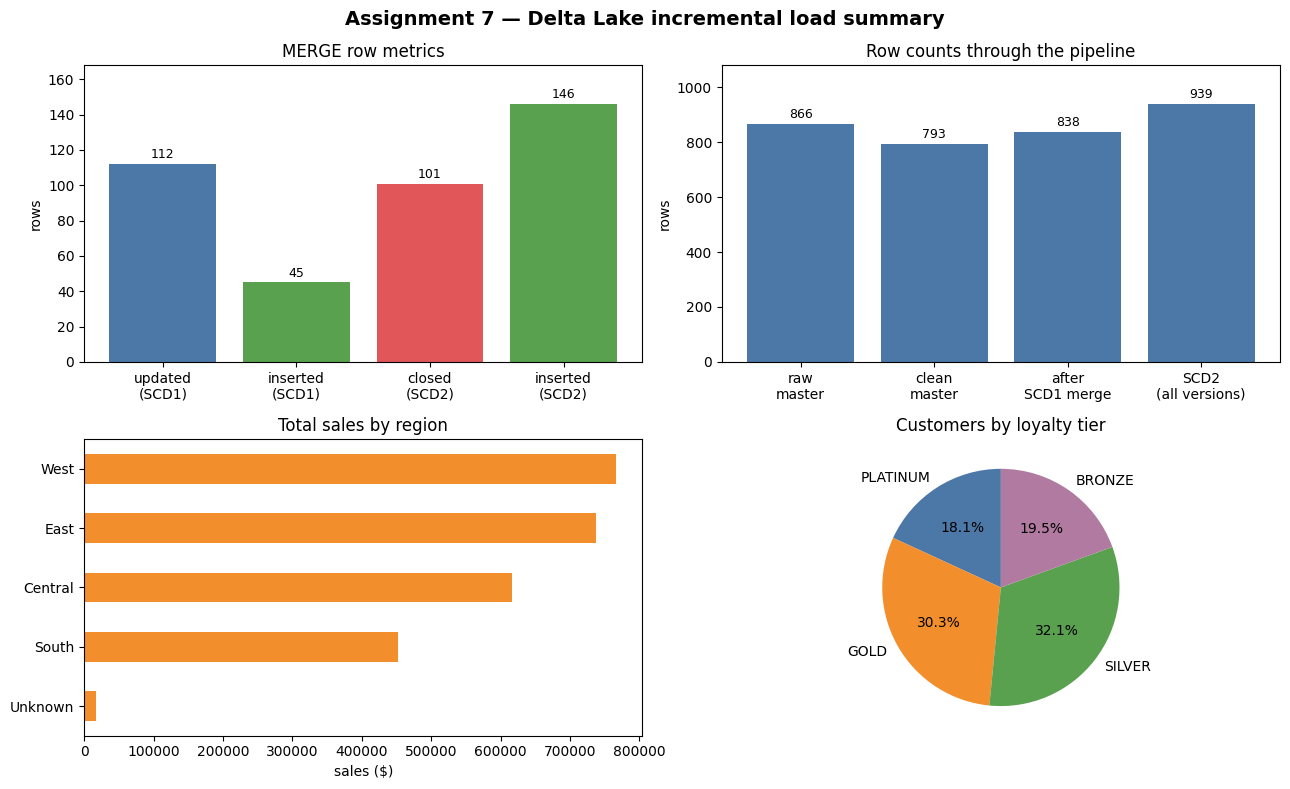

In [33]:
%matplotlib inline
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Assignment 7 — Delta Lake incremental load summary", fontsize=14, fontweight="bold")

ax = axes[0, 0]
labels = ["updated\n(SCD1)", "inserted\n(SCD1)", "closed\n(SCD2)", "inserted\n(SCD2)"]
vals = [scd1_metrics["num_target_rows_updated"], scd1_metrics["num_target_rows_inserted"],
        scd2_metrics["num_target_rows_updated"], scd2_metrics["num_target_rows_inserted"]]
bars = ax.bar(labels, vals, color=["#4C78A8", "#59A14F", "#E15759", "#59A14F"])
ax.bar_label(bars, padding=2, fontsize=9)
ax.set_title("MERGE row metrics"); ax.set_ylabel("rows")
ax.margins(y=0.15)

ax = axes[0, 1]
stages = ["raw\nmaster", "clean\nmaster", "after\nSCD1 merge", "SCD2\n(all versions)"]
counts = [len(master_raw), len(t_silver), len(t_scd1), len(t_scd2)]
bars = ax.bar(stages, counts, color="#4C78A8")
ax.bar_label(bars, fmt="%d", padding=2, fontsize=9)
ax.set_title("Row counts through the pipeline"); ax.set_ylabel("rows")
ax.margins(y=0.15)

ax = axes[1, 0]
by_region["sales"].sort_values().plot(kind="barh", ax=ax, color="#F28E2B")
ax.set_title("Total sales by region"); ax.set_xlabel("sales ($)"); ax.set_ylabel("")

ax = axes[1, 1]
tier_counts = by_tier["customers"]
ax.pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", startangle=90,
       colors=["#4C78A8", "#F28E2B", "#59A14F", "#B07AA1"])
ax.set_title("Customers by loyalty tier")

plt.tight_layout()
chart_path = SHOTS_DIR / "06_final_output" / "04_summary_charts.png"
chart_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(chart_path, dpi=140, bbox_inches="tight", facecolor="white")
print(f"chart saved -> {chart_path.relative_to(PROJECT_ROOT)}")
plt.show()

In [34]:
banner("EXPORTS AND RUN SUMMARY")

final_scd1.to_csv(OUTPUT_DIR / "final_customer_scd1.csv", index=False)
final_scd2.to_csv(OUTPUT_DIR / "final_customer_scd2.csv", index=False)
by_region.to_csv(OUTPUT_DIR / "summary_by_region.csv")
classified[["customer_id", "customer_name", "change_type"]].to_csv(
    OUTPUT_DIR / "incremental_change_classification.csv", index=False)

RUN_SUMMARY = {
    "assignment": "Assignment 7 — Delta Lake MERGE / incremental processing",
    "engine": f"delta-rs {deltalake.__version__} (native Delta Lake)",
    "executed_at_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC"),
    "source": {
        "master_csv_rows": int(len(master_raw)),
        "incremental_csv_rows": int(len(incr_raw)),
    },
    "cleaning": {
        "master_rows_removed": int(master_report["rows_removed"]),
        "master_null_key_rows_dropped": int(master_report["dropped_null_key"]),
        "master_exact_duplicates_dropped": int(master_report["dropped_exact_duplicates"]),
        "master_duplicate_keys_dropped": int(master_report["dropped_duplicate_keys"]),
        "master_null_cells_filled": int(master_report["nulls_filled"]),
        "incremental_duplicates_dropped": int(incr_report["dropped_exact_duplicates"]),
    },
    "change_classification": {
        "new": EXPECTED_NEW, "changed": EXPECTED_CHANGED, "unchanged": EXPECTED_UNCHANGED,
    },
    "scd1": {
        "rows_before": int(ROWS_BEFORE_SCD1),
        "rows_after": int(ROWS_AFTER_SCD1),
        "updated": int(scd1_metrics["num_target_rows_updated"]),
        "inserted": int(scd1_metrics["num_target_rows_inserted"]),
        "delta_version": int(DeltaTable(str(TBL_SCD1)).version()),
    },
    "scd2": {
        "rows_before": int(ROWS_BEFORE_SCD2),
        "rows_after": int(ROWS_AFTER_SCD2),
        "versions_closed": int(scd2_metrics["num_target_rows_updated"]),
        "rows_inserted": int(scd2_metrics["num_target_rows_inserted"]),
        "current_rows": int(final_scd2["is_current"].sum()),
        "delta_version": int(DeltaTable(str(TBL_SCD2)).version()),
    },
    "validation": {
        "scd1_checks_passed": int(res1["passed"].sum()),
        "scd2_checks_passed": int(res2["passed"].sum()),
        "suite_checks_passed": int(suite_df["passed"].sum()),
        "all_passed": bool(res1["passed"].all() and res2["passed"].all() and suite_df["passed"].all()),
    },
    "business": {
        "customers": int(len(final_scd1)),
        "total_sales": round(float(final_scd1["total_sales"].sum()), 2),
        "total_profit": round(float(final_scd1["total_profit"].sum()), 2),
    },
}

with open(OUTPUT_DIR / "run_summary.json", "w") as f:
    json.dump(RUN_SUMMARY, f, indent=2)

print("files written to output/:")
for p in sorted(OUTPUT_DIR.glob("*.*")):
    print(f"  {p.name:<42} {p.stat().st_size / 1024:8.1f} KB")

print("\nRUN SUMMARY")
print(json.dumps(RUN_SUMMARY, indent=2))

EXPORTS AND RUN SUMMARY


files written to output/:
  final_customer_scd1.csv                       134.9 KB
  final_customer_scd2.csv                       217.1 KB
  incremental_change_classification.csv           4.6 KB
  run_summary.json                                1.1 KB
  summary_by_region.csv                           0.2 KB

RUN SUMMARY
{
  "assignment": "Assignment 7 \u2014 Delta Lake MERGE / incremental processing",
  "engine": "delta-rs 1.6.2 (native Delta Lake)",
  "executed_at_utc": "2026-08-03 01:19:49 UTC",
  "source": {
    "master_csv_rows": 866,
    "incremental_csv_rows": 162
  },
  "cleaning": {
    "master_rows_removed": 73,
    "master_null_key_rows_dropped": 3,
    "master_exact_duplicates_dropped": 45,
    "master_duplicate_keys_dropped": 25,
    "master_null_cells_filled": 123,
    "incremental_duplicates_dropped": 5
  },
  "change_classification": {
    "new": 45,
    "changed": 101,
    "unchanged": 11
  },
  "scd1": {
    "rows_before": 793,
    "rows_after": 838,
    "updated": 1

---
## 7. Explanation

### What was done

The raw customer snapshot was landed **as-is** into a bronze Delta table, cleaned into a silver
table, and then merged with an incremental feed into two gold tables — one SCD Type 1 and one
SCD Type 2. Every write is a Delta commit, so each table carries a full transaction log and can
be queried at any earlier version.

### Cleaning

The raw snapshot carried the three problems that break most incremental pipelines: **nulls**,
**duplicates**, and **inconsistent strings**. All three were handled by one shared function so
that the master and the incremental feed are normalised identically — if they were cleaned
differently, the hash comparison would report spurious changes and the merge key could fail to
match. Rows without a `customer_id` were dropped (unmergeable), exact duplicates were removed,
and where a `customer_id` appeared more than once the record with the newest `record_updated_at`
was kept. That last step is not cosmetic: **`MERGE` raises an error if a single source row
matches the same target row more than once**, so de-duplicating the source is a hard requirement,
not a nicety.

### Why `MERGE` instead of overwrite

Rewriting the whole table on every batch is simple but wasteful, and it destroys the ability to
see what changed. `MERGE` touches only the affected files, runs as a single ACID transaction, and
records the operation — with row-level metrics — in the transaction log. Readers querying the
table during the merge see the old version, never a half-written one.

### SCD Type 1 vs Type 2

Type 1 keeps one row per customer and overwrites it, which is the right choice when only the
current state matters and storage or query simplicity is the priority. Type 2 keeps every version
with `effective_start_date` / `effective_end_date` / `is_current`, which is what you need to answer
"what was this customer's segment when that order was placed?" — the cost is a larger table and a
mandatory `WHERE is_current = true` on every "current state" query.

The Type 2 merge needs the **two-part source union** because one source row can only act on one
target row: Part A (keyed) closes the outgoing version, Part B (`merge_key = NULL`, therefore never
matched) inserts the incoming one. A `record_hash` over the tracked attributes is what decides
whether a row genuinely changed — without it, a batch that re-sends identical rows would create a
new version for every customer every day.

### Results

The 866-row raw snapshot cleaned down to 793 unique customers. The 162-row feed cleaned to 157
rows: 45 new customers, 101 genuine changes, 11 rows identical to what was already stored. The
SCD1 table therefore went from 793 to 838 rows (45 inserts, 112 rows matched and overwritten), and
the SCD2 table went from 793 to 939 rows — 838 current versions plus 101 expired ones. Every
validation check passed: no duplicate business keys, no null cells, exactly one current row per
customer in the Type 2 table, no gaps or overlaps in the effective-date ranges, and time travel
back to version 0 reproduces the pre-merge state exactly.

### Trade-offs and next steps

The tables here are unpartitioned, which is fine at this size but would need partitioning (by
`region`, say) and periodic `OPTIMIZE` / `Z-ORDER` at scale. Surrogate keys are allocated in
blocks, so the sequence has gaps — harmless, since a surrogate key only has to be unique. A
production version would also enable Change Data Feed to stream downstream consumers, schedule
`VACUUM` to retire old file versions once the time-travel window has passed, and add expectation
checks that quarantine bad rows instead of imputing them.